<a href="https://colab.research.google.com/github/Deveshk78/AI-training-class-02/blob/main/sentiment_classification_IMDB_Movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, losses, models
import matplotlib.pyplot as plt

print(f"Using TensorFlow Version: {tf.__version__}")

# 1. Load the IMDB dataset (pre-indexed integer sequences)
# We limit the vocabulary to the top 10,000 most frequent words
MAX_FEATURES = 10000
MAX_LEN = 200

print("Loading IMDB dataset...")
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=MAX_FEATURES)

Using TensorFlow Version: 2.21.0
Loading IMDB dataset...


In [2]:
# 2. Pad sequences so all reviews have the same length (MAX_LEN)
print("Padding sequences...")
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train, maxlen=MAX_LEN)
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test, maxlen=MAX_LEN)

Padding sequences...


In [3]:
# 3. Build the Neural Network Model
print("Building the model architecture...")
model = models.Sequential([
    # Converts integer indices to dense vector embeddings
    layers.Embedding(input_dim=MAX_FEATURES, output_dim=128, input_length=MAX_LEN),
    layers.SpatialDropout1D(0.3),

    # Aggregates features across the length of the review
    layers.GlobalAveragePooling1D(),

    # Hidden dense layer with ReLU activation
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    # Output layer with a single node and sigmoid activation (0 = Negative, 1 = Positive)
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss=losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Building the model architecture...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 4. Train the Model
EPOCHS = 5
BATCH_SIZE = 256

print("\nStarting model training...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)


Starting model training...
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6436 - loss: 0.6585 - val_accuracy: 0.7762 - val_loss: 0.5544
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8204 - loss: 0.4380 - val_accuracy: 0.8596 - val_loss: 0.3516
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8730 - loss: 0.3091 - val_accuracy: 0.8610 - val_loss: 0.3320
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8968 - loss: 0.2589 - val_accuracy: 0.8774 - val_loss: 0.2976
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9121 - loss: 0.2240 - val_accuracy: 0.8832 - val_loss: 0.2903


In [5]:
# 5. Evaluate on the Test Set
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Evaluating model on test data...
Test Accuracy: 87.43%
Test Loss: 0.2992


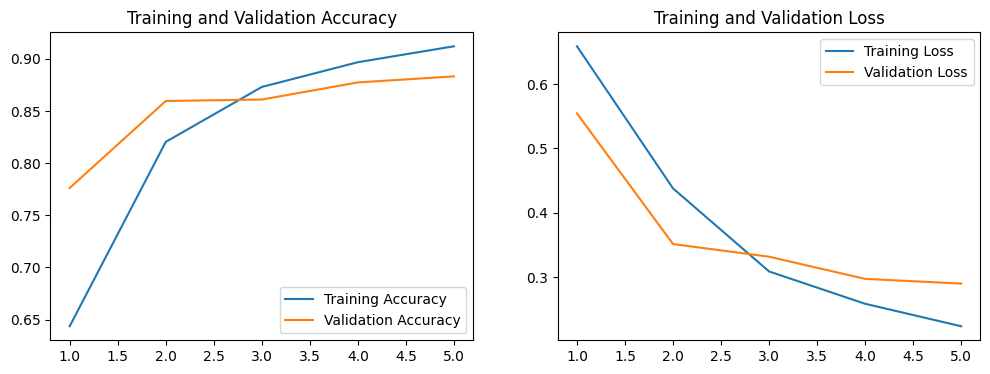

In [6]:
# 6. Optional: Plot Training History (Accuracy & Loss)
try:
    history_dict = history.history
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']

    epochs_range = range(1, EPOCHS + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()
except Exception as e:
    print(f"Skipping plot generation (non-interactive environment detected): {e}")

In [7]:
# 7. Test Predictions with Custom Review Sentences
word_index = tf.keras.datasets.imdb.get_word_index()
# Offset indices standard in Keras dataset loader
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3
reverse_word_index = {v: k for k, v in word_index.items()}

In [8]:
def predict_sentiment(review_text):
    # Basic text tokenization & mapping to word index
    tokens = [word_index.get(word.lower(), 2) for word in review_text.split()]
    padded = tf.keras.preprocessing.sequence.pad_sequences([tokens], maxlen=MAX_LEN)
    prediction = model.predict(padded)[0][0]
    sentiment = "Positive 😃" if prediction > 0.5 else "Negative 😞"
    print(f"\nReview: '{review_text}'")
    print(f"Prediction Score: {prediction:.4f} => Sentiment: {sentiment}")

In [9]:
# Run inference examples
predict_sentiment("This movie was an absolute masterpiece. The acting and direction were phenomenal!")
predict_sentiment("Terrible waste of time. The plot made no sense and the acting was wooden.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step

Review: 'This movie was an absolute masterpiece. The acting and direction were phenomenal!'
Prediction Score: 0.2410 => Sentiment: Negative 😞
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

Review: 'Terrible waste of time. The plot made no sense and the acting was wooden.'
Prediction Score: 0.0453 => Sentiment: Negative 😞
